# Warm-up — The Lucky Trader

**AI-powered Investment and Risk Management (25882) · Lecture 8 · UTS Business School**

Twenty minutes, three acts, and one uncomfortable conclusion.

You need no finance background and no maths beyond averages. Run the cells in order
and **do not skip ahead** — two of the three acts depend on you not knowing what
happens next.

There is also a five-minute coda at the end that checks your environment is ready for
this week's labs. Run it even if you stop reading.

## 0. Does everything work?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots


try:
    import airm8
    from airm8 import airm_layout, NAVY, RED, TEAL, ORANGE, GREY
    print("airm8 loaded")
except ImportError:
    print("airm8 not found — put airm8.py beside this notebook.")
    raise

rng = np.random.default_rng(23)
print(f"numpy {np.__version__} | pandas {pd.__version__}")
print("Ready.")

airm8 loaded
numpy 2.4.6 | pandas 3.0.5
Ready.


---
# Act 1 — A track record

A fund manager approaches you. Here is their record over the last five years.

In [2]:
N_TRADERS, N_MONTHS = 1_000, 60
returns = rng.normal(0, 0.05, size=(N_TRADERS, N_MONTHS))

sharpe = returns.mean(1) / returns.std(1, ddof=1) * np.sqrt(12)
star = sharpe.argmax()
track = returns[star]

annual = track.reshape(-1, 12).sum(1)
print("           THE TRACK RECORD\n")
for k, a in enumerate(annual, 1):
    print(f"   Year {k}:  {a:+7.1%}")
print(f"\n   Total return      {np.exp(track.sum()) - 1:+.0%}")
print(f"   Annualised Sharpe {sharpe[star]:.2f}")
print(f"   Winning years     {(annual > 0).sum()} of {len(annual)}")
print(f"   Worst month       {track.min():.1%}")

           THE TRACK RECORD

   Year 1:   +28.2%
   Year 2:   +20.7%
   Year 3:   +38.2%
   Year 4:   +16.4%
   Year 5:   +12.6%

   Total return      +219%
   Annualised Sharpe 1.51
   Winning years     5 of 5
   Worst month       -6.0%


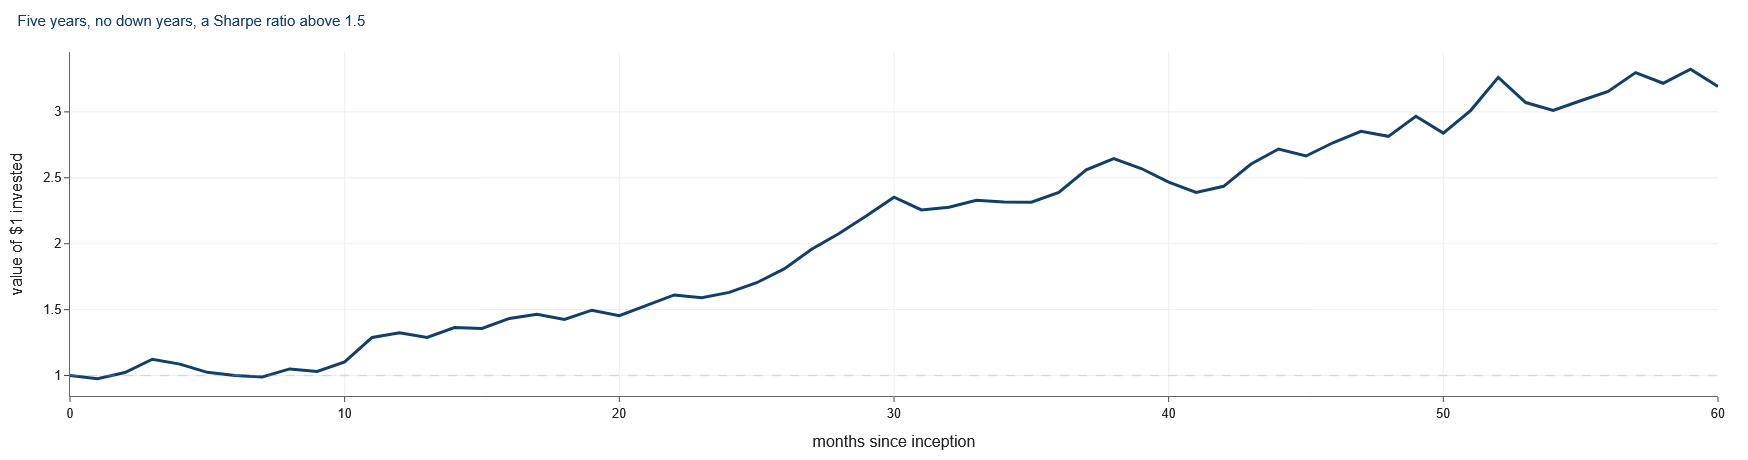

In [3]:
equity = np.exp(np.concatenate([[0], track.cumsum()]))
fig = go.Figure(go.Scatter(y=equity, mode="lines",
                           line=dict(color=NAVY, width=3),
                           name="the fund"))
fig.add_hline(y=1, line=dict(color=GREY, width=1.5, dash="dash"))
fig.update_xaxes(title="months since inception")
fig.update_yaxes(title="value of $1 invested")
airm_layout(fig, "Five years, no down years, a Sharpe ratio above 1.5")

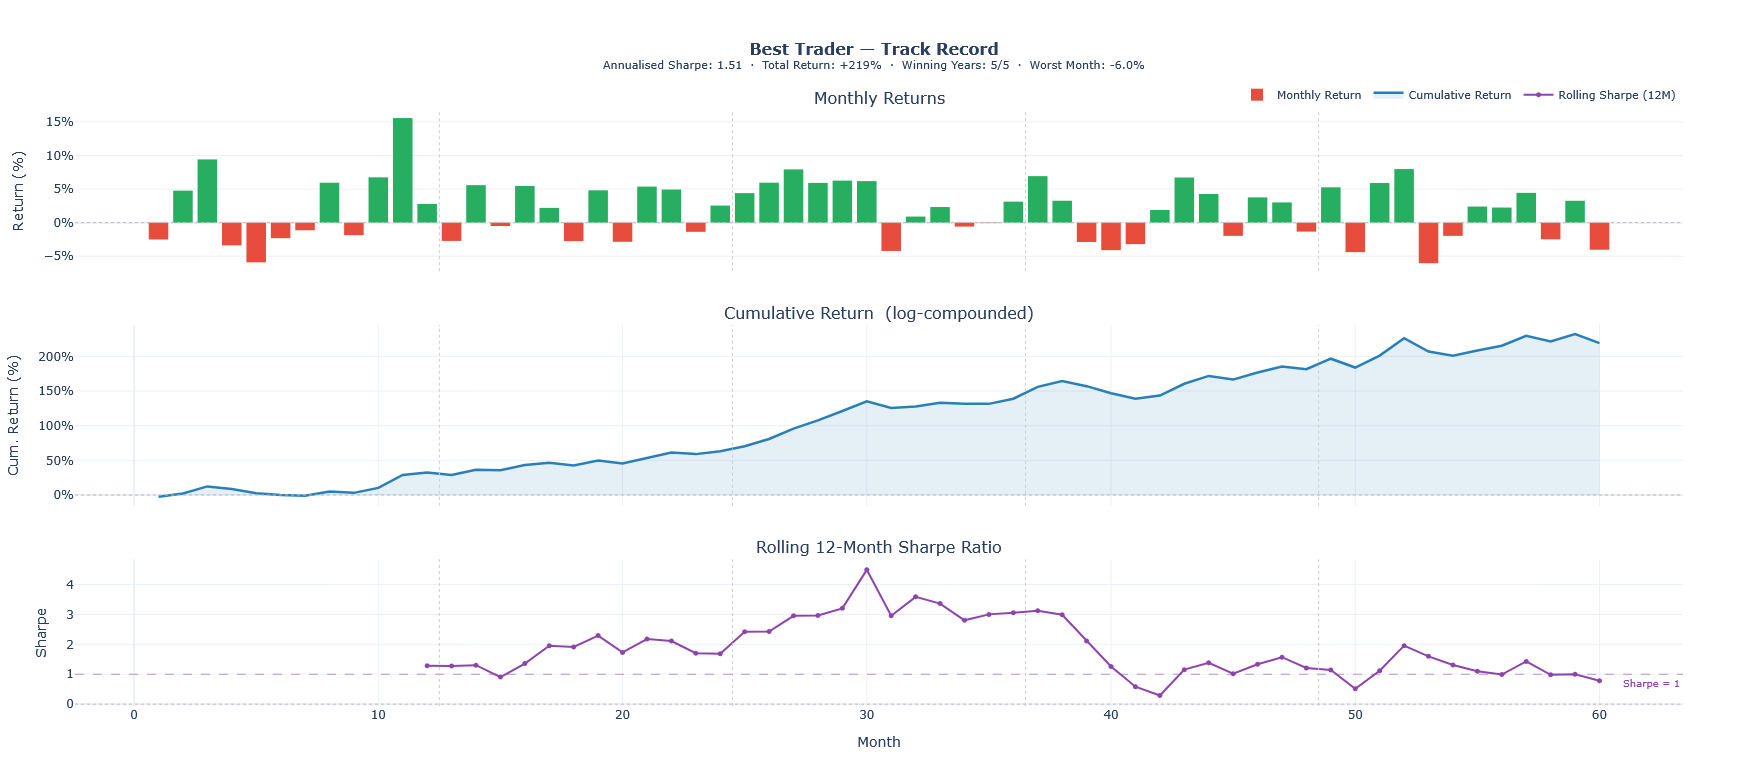

In [4]:
# ── Derived series ─────────────────────────────────────────────────────────────
cum_ret = np.exp(np.cumsum(track)) - 1       # log-compounded cumulative return

WINDOW  = 12                                 # rolling window for Sharpe
roll_sh = np.full(N_MONTHS, np.nan)
for i in range(WINDOW - 1, N_MONTHS):
    w = track[i - WINDOW + 1 : i + 1]
    roll_sh[i] = w.mean() / w.std(ddof=1) * np.sqrt(12)

months_idx = np.arange(1, N_MONTHS + 1)
year_num   = (months_idx - 1) // 12 + 1     # 1-based year
month_num  = (months_idx - 1) %  12 + 1     # 1-based month within year

best_m  = np.argmax(track)
worst_m = np.argmin(track)

# ── Custom hover payload ───────────────────────────────────────────────────────
# list-of-lists so string entries (win/loss label) are allowed
cdata = [
    [
        int(year_num[i]),                                              # [0] year
        int(month_num[i]),                                             # [1] month in year
        f"{track[i] * 100:+.2f}%",                                    # [2] monthly return
        f"{cum_ret[i] * 100:+.2f}%",                                  # [3] cum return
        (f"{roll_sh[i]:.2f}"
         if not np.isnan(roll_sh[i]) else "N/A (< 12 months)"),       # [4] rolling sharpe
        "📈 Positive" if track[i] > 0 else "📉 Negative",             # [5] win / loss
        ("⭐ Best month"  if i == best_m  else
         "⚠️ Worst month" if i == worst_m else ""),                    # [6] notable flag
    ]
    for i in range(N_MONTHS)
]

# ── Shared hover template ──────────────────────────────────────────────────────
# Used on all three traces so full context is available regardless of panel.
HTMPL = (
    "<b>Year %{customdata[0]} · Month %{customdata[1]}</b>"
    "  %{customdata[6]}<br>"
    "<span style='color:#bbb'>─────────────────────────────</span><br>"
    "🗓 Monthly return    : <b>%{customdata[2]}</b>  %{customdata[5]}<br>"
    "📈 Cumulative return : <b>%{customdata[3]}</b><br>"
    "⚡ Rolling Sharpe    : <b>%{customdata[4]}</b><br>"
    "<extra></extra>"           # hides the default trace-name bubble
)

# ── Figure skeleton ────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        "Monthly Returns",
        "Cumulative Return  (log-compounded)",
        "Rolling 12-Month Sharpe Ratio",
    ],
    vertical_spacing=0.09,
    row_heights=[0.33, 0.37, 0.30],
)

# ── Panel 1 : Monthly returns (colour-coded bars) ─────────────────────────────
fig.add_trace(go.Bar(
    x=months_idx,
    y=track * 100,
    marker=dict(
        color=["#27ae60" if r > 0 else "#e74c3c" for r in track],
        line_width=0,
    ),
    name="Monthly Return",
    customdata=cdata,
    hovertemplate=HTMPL,
), row=1, col=1)

# ── Panel 2 : Cumulative return (filled area) ─────────────────────────────────
fig.add_trace(go.Scatter(
    x=months_idx,
    y=cum_ret * 100,
    mode="lines",
    fill="tozeroy",
    fillcolor="rgba(41,128,185,0.12)",
    line=dict(color="#2980b9", width=2.5),
    name="Cumulative Return",
    customdata=cdata,
    hovertemplate=HTMPL,
), row=2, col=1)

# ── Panel 3 : Rolling Sharpe ──────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=months_idx,
    y=roll_sh,
    mode="lines+markers",
    marker=dict(size=5, color="#8e44ad"),
    line=dict(color="#8e44ad", width=2),
    name="Rolling Sharpe (12M)",
    customdata=cdata,
    hovertemplate=HTMPL,
), row=3, col=1)

# ── Reference lines ────────────────────────────────────────────────────────────
for row in range(1, 4):
    fig.add_hline(y=0, line_dash="dot", line_color="#bbb",
                  line_width=1, row=row, col=1)

fig.add_hline(                             # Sharpe = 1 benchmark
    y=1, row=3, col=1,
    line_dash="dash", line_color="#8e44ad",
    line_width=1.2, opacity=0.55,
    annotation_text="Sharpe = 1",
    annotation_position="bottom right",
    annotation_font=dict(color="#8e44ad", size=10),
)

# ── Year-boundary vertical lines ───────────────────────────────────────────────
N_YEARS = N_MONTHS // 12
for y in range(1, N_YEARS):
    fig.add_vline(x=y * 12 + 0.5,
                  line_dash="dot", line_color="#ccc", line_width=1)

# ── Global layout ──────────────────────────────────────────────────────────────
total_ret = np.exp(track.sum()) - 1
win_years = (annual > 0).sum()

fig.update_layout(
    title=dict(
        text=(
            f"<b>Best Trader — Track Record</b><br>"
            f"<sup>Annualised Sharpe: {sharpe[star]:.2f}  ·  "
            f"Total Return: {total_ret:+.0%}  ·  "
            f"Winning Years: {win_years}/{len(annual)}  ·  "
            f"Worst Month: {track.min():.1%}</sup>"
        ),
        x=0.5, xanchor="center", font_size=16,
    ),
    height=760,
    template="plotly_white",
    hovermode="closest",    # full context tooltip on the hovered trace
    showlegend=True,
    legend=dict(orientation="h", y=1.05, xanchor="right", x=1, font_size=11),
    margin=dict(l=65, r=65, t=110, b=45),
)

# ── Axis labels ────────────────────────────────────────────────────────────────
fig.update_yaxes(title_text="Return (%)",      ticksuffix="%", row=1, col=1)
fig.update_yaxes(title_text="Cum. Return (%)", ticksuffix="%", row=2, col=1)
fig.update_yaxes(title_text="Sharpe",                          row=3, col=1)
fig.update_xaxes(title_text="Month",                           row=3, col=1)

fig.show()

# Optional — save to HTML for sharing
# fig.write_html("track_record.html")

### Before you continue

A Sharpe ratio of 1.5 would place this manager comfortably in the upper reaches of the
hedge fund industry. Five winning years out of five. The worst single month is
unpleasant but survivable.

**Would you give them your money?** Decide now, in your head, before running the next
cell.

In [5]:
print("Where that track record came from:\n")
print(f"   {N_TRADERS:,} simulated traders")
print(f"   Each one drew {N_MONTHS} monthly returns at random")
print(f"   Every draw had a TRUE expected return of exactly ZERO")
print(f"\n   We then picked the best of the {N_TRADERS:,} and showed you only that one.")
print(f"\n   Trader #{star} has no skill. Nobody in this simulation has any skill.")

Where that track record came from:

   1,000 simulated traders
   Each one drew 60 monthly returns at random
   Every draw had a TRUE expected return of exactly ZERO

   We then picked the best of the 1,000 and showed you only that one.

   Trader #349 has no skill. Nobody in this simulation has any skill.


## The manager was a coin flip

Nothing in the simulation had an edge. Every one of the thousand traders had a true
expected return of exactly zero. We ran them, sorted by outcome, and showed you the
winner.

This is not a trick played on you. It is the structure of the fund management
industry, of the academic literature, and of your own backtesting. **You almost never
see the losers.** Funds that perform badly close and disappear from the databases.
Strategies that fail never get written up. Backtests that disappoint get quietly
revised.

Here is what the other 999 look like.

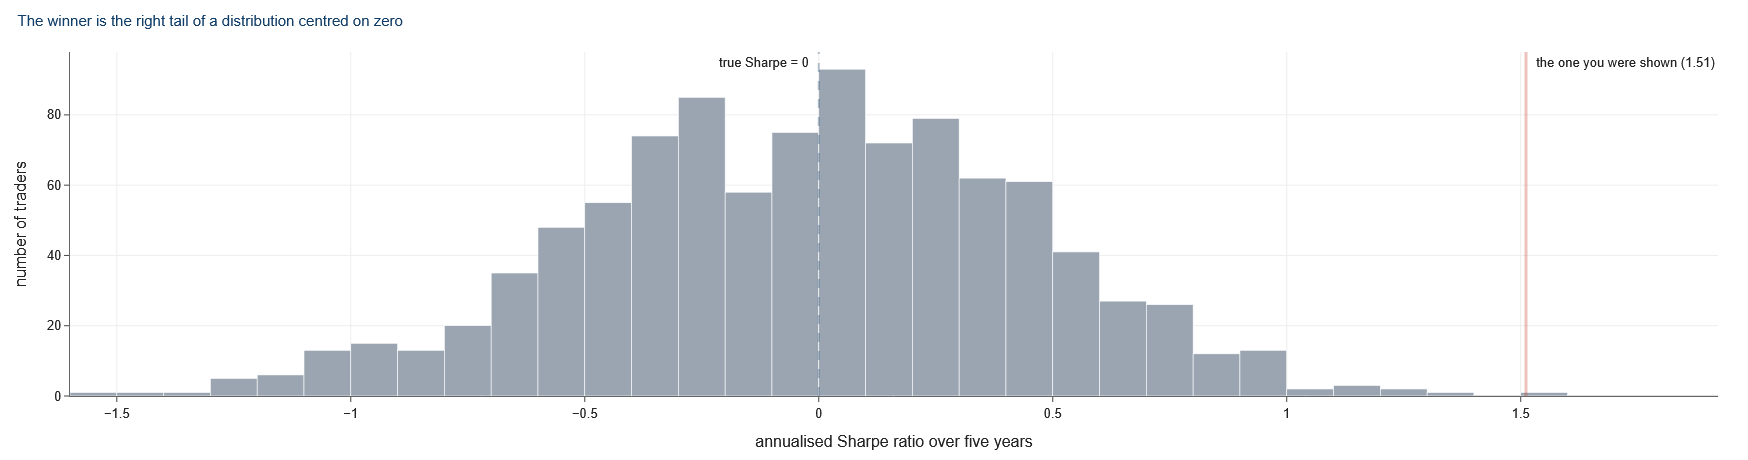

In [6]:
fig = go.Figure(go.Histogram(x=sharpe, marker_color=GREY, nbinsx=45,
                             name="all 1,000 traders"))
fig.add_vline(x=sharpe[star], line=dict(color=RED, width=3),
              annotation_text=f"  the one you were shown ({sharpe[star]:.2f})",
              annotation_position="top right")
fig.add_vline(x=0, line=dict(color=NAVY, width=2, dash="dash"),
              annotation_text="true Sharpe = 0  ",
              annotation_position="top left")
fig.update_xaxes(title="annualised Sharpe ratio over five years")
fig.update_yaxes(title="number of traders")
airm_layout(fig, "The winner is the right tail of a distribution centred on zero")

In [7]:
print(f"Best Sharpe    {sharpe.max():6.2f}")
print(f"Median Sharpe  {np.median(sharpe):6.2f}")
print(f"Worst Sharpe   {sharpe.min():6.2f}")
print(f"\nTraders with a POSITIVE five-year Sharpe: "
      f"{(sharpe > 0).sum()} of {N_TRADERS:,}")
print(f"Traders who beat a Sharpe of 1.0:        "
      f"{(sharpe > 1).sum()} of {N_TRADERS:,}")

Best Sharpe      1.51
Median Sharpe   -0.00
Worst Sharpe    -1.51

Traders with a POSITIVE five-year Sharpe: 495 of 1,000
Traders who beat a Sharpe of 1.0:        9 of 1,000


<details>
<summary><b>The maths: how lucky should the luckiest of 1,000 be?</b> (click to expand)</summary>

A Sharpe ratio estimated from $T$ observations has a standard error of roughly
$1/\sqrt{T}$ per period. Over $T = 60$ months that is $0.129$, or
$0.129 \times \sqrt{12} \approx 0.45$ in annualised terms.

The maximum of $n$ standard normal draws grows like $\sqrt{2 \ln n}$. For
$n = 1{,}000$ that is about $3.7$ standard errors.

So the best of a thousand skill-free traders should post an annualised Sharpe of
roughly

$$3.7 \times 0.45 \approx 1.7,$$

against the $1.5$ we observed. The approximation runs slightly high — it is an
upper bound on the *expected* maximum — but it lands within a rounding error of
reality.

**Nothing surprising happened.** A track record that looks like genuine skill is the
arithmetically expected outcome of searching a thousand records for the best one.
The next cell checks this against the simulation rather than asking you to take it
on trust.

</details>

In [8]:
se = np.sqrt(12 / N_MONTHS)                    # sd of an annualised Sharpe
expected_max = se * np.sqrt(2 * np.log(N_TRADERS))

print(f"Standard error of a {N_MONTHS}-month Sharpe   {se:.2f}")
print(f"Expected best of {N_TRADERS:,}, from theory     {expected_max:.2f}")
print(f"Best we actually observed                {sharpe.max():.2f}")
print(f"\nThe theory anticipates the result to within "
      f"{abs(sharpe.max() - expected_max):.2f}.")
print("Nothing unusual happened. This is what searching a thousand records does.")

Standard error of a 60-month Sharpe   0.45
Expected best of 1,000, from theory     1.66
Best we actually observed                1.51

The theory anticipates the result to within 0.15.
Nothing unusual happened. This is what searching a thousand records does.


---
# Act 2 — Now you are the researcher

Enough about fund managers. Your turn.

Below are **200 candidate signals** and **one target series** you would like to
predict — think of it as next month's return on some asset. Twenty years of monthly
data.

Your job is the one every quant does: **find the signal that predicts the target.**

In [9]:
P, T = 200, 240

X = rng.normal(size=(T, P))
y = rng.normal(size=T)

signals = pd.DataFrame(X, columns=[f"signal_{i:03d}" for i in range(P)])
target = pd.Series(y, name="target")

print(f"{signals.shape[1]} candidate signals, {len(target)} months of data.")
signals.iloc[:5, :12].round(3)

200 candidate signals, 240 months of data.


,signal_000,signal_001,signal_002,signal_003,signal_004,signal_005,signal_006,signal_007,signal_008,signal_009,signal_010,signal_011
0,0.823,-1.039,-0.803,-0.822,-0.553,-0.565,1.357,0.539,0.035,0.923,1.281,0.941
1,-0.540,-0.200,1.590,2.492,-1.313,-1.520,0.378,1.434,0.111,-2.255,2.070,-0.859
2,-0.418,1.000,1.816,0.198,-0.357,-1.298,-0.804,-0.213,-1.610,-1.224,-0.619,0.337
3,-1.178,1.276,0.492,0.916,-1.013,-0.737,0.117,1.361,-0.644,-2.114,0.005,0.944
4,-0.661,-1.677,2.037,0.776,-1.847,-1.502,0.629,1.228,-0.794,-0.627,0.899,0.810


In [10]:
# Correlation and t-statistic of every candidate against the target.
def screen(signals, target):
    n = len(target)
    r = signals.corrwith(target)
    t = r * np.sqrt((n - 2) / np.maximum(1 - r ** 2, 1e-12))
    p = 2 * (1 - stats.t.cdf(np.abs(t), n - 2))
    return pd.DataFrame({"correlation": r, "t_stat": t, "p_value": p})

results = screen(signals, target)
best = results.t_stat.abs().idxmax()
best_t    = results.loc[best, "t_stat"]
best_corr = results.loc[best, "correlation"]
best_p    = results.loc[best, "p_value"]

print("TOP 5 PREDICTORS\n")
print(results.reindex(results.t_stat.abs().sort_values(ascending=False).index)
             .head().round(4).to_string())

print(f"\nThe winner is {best}:")
print(f"   correlation with the target  {results.loc[best, 'correlation']:+.3f}")
print(f"   t-statistic                  {results.loc[best, 't_stat']:+.2f}")
print(f"   p-value                      {results.loc[best, 'p_value']:.4f}")
print(f"\n   Signals clearing |t| > 1.96: "
      f"{(results.t_stat.abs() > 1.96).sum()} of {P}")

TOP 5 PREDICTORS

            correlation  t_stat  p_value
signal_114       0.2041  3.2158   0.0015
signal_088       0.1767  2.7699   0.0061
signal_018      -0.1712 -2.6800   0.0079
signal_094      -0.1697 -2.6558   0.0084
signal_170      -0.1571 -2.4542   0.0148

The winner is signal_114:
   correlation with the target  +0.204
   t-statistic                  +3.22
   p-value                      0.0015

   Signals clearing |t| > 1.96: 14 of 200


A p-value below 0.001. In most journals that is not merely publishable, it is a
headline. If you had found this in a real dataset you would name the signal, write
the economic story explaining why it works, and build a strategy around it.

### Commit before you continue

Edit the cell below with your honest guess, then run it. **No going back afterwards.**

In [11]:
# Of the 200 candidate signals, how many do you think are genuinely
# related to the target? Replace the None with a number.

MY_GUESS = None

if MY_GUESS is None:
    print("Put a number in MY_GUESS and run this cell again.")
else:
    print(f"You guessed {MY_GUESS} of {P} signals are real.")
    print("Now run the next cell.")

Put a number in MY_GUESS and run this cell again.


---
# Act 3 — The reveal

In [12]:
print("Look again at how the data was built:\n")
print("   X = rng.normal(size=(T, P))      <- 200 columns of pure noise")
print("   y = rng.normal(size=T)           <- drawn INDEPENDENTLY of X")
print("\nThere is no relationship. Not a weak one. Not a subtle one. NONE.")
print(f"\n   Genuinely predictive signals: 0 of {P}")
print(f"   Signals that looked significant: {(results.t_stat.abs() > 1.96).sum()}")
print(f"   Best p-value found: {results.p_value.min():.4f}")

Look again at how the data was built:

   X = rng.normal(size=(T, P))      <- 200 columns of pure noise
   y = rng.normal(size=T)           <- drawn INDEPENDENTLY of X

There is no relationship. Not a weak one. Not a subtle one. NONE.

   Genuinely predictive signals: 0 of 200
   Signals that looked significant: 14
   Best p-value found: 0.0015


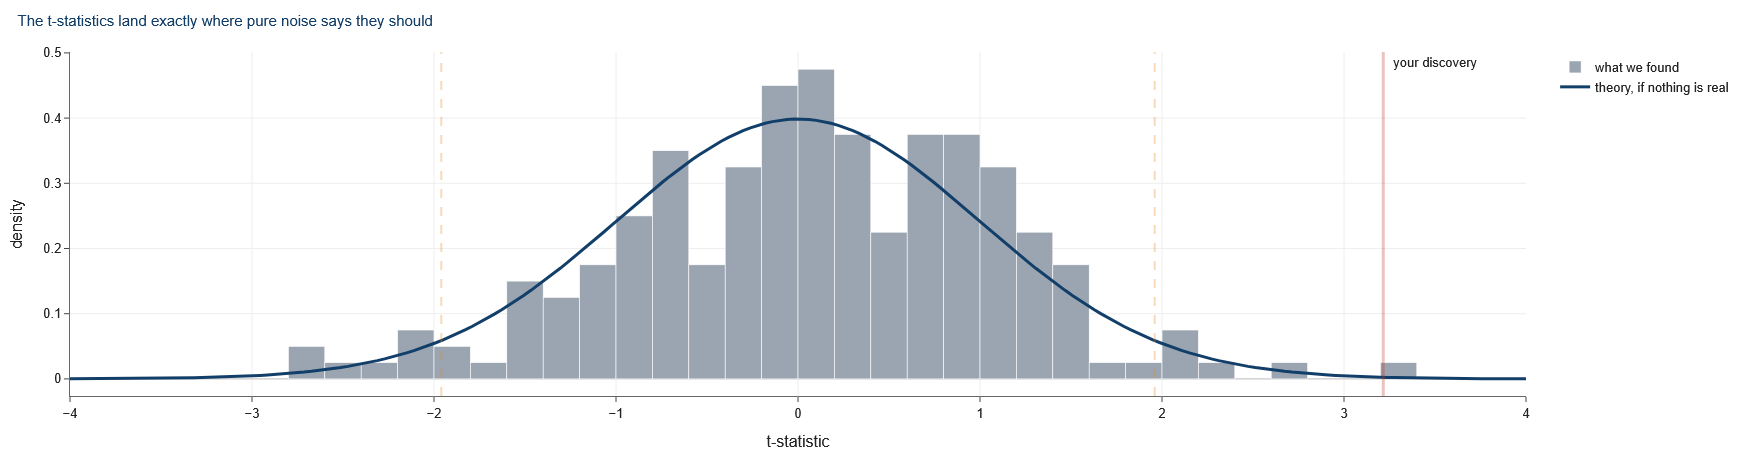

In [13]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=results.t_stat, marker_color=GREY, nbinsx=40,
                           histnorm="probability density", name="what we found"))

grid = np.linspace(-4, 4, 200)
fig.add_trace(go.Scatter(x=grid, y=stats.t.pdf(grid, T - 2), mode="lines",
                         line=dict(color=NAVY, width=3),
                         name="theory, if nothing is real"))
for s in (-1, 1):
    fig.add_vline(x=s * 1.96, line=dict(color=ORANGE, width=2, dash="dash"))
fig.add_vline(x=results.loc[best, "t_stat"], line=dict(color=RED, width=3),
              annotation_text="  your discovery", annotation_position="top right")
fig.update_xaxes(title="t-statistic")
fig.update_yaxes(title="density")
airm_layout(fig, "The t-statistics land exactly where pure noise says they should")

The histogram sits on top of the theoretical curve. Nothing anomalous happened. About
5% of the signals cleared $|t| > 1.96$, which is **precisely what a 5% significance
level means**: reject 5% of the time when nothing is there.

The problem was never the statistics. The problem was that we ran 200 tests and
reported one.

In [14]:
bonferroni = stats.t.ppf(1 - 0.025 / P, T - 2)
print(f"Conventional hurdle              |t| > 1.96")
print(f"Bonferroni hurdle for {P} tests   |t| > {bonferroni:.2f}")
print(f"Our best discovery               |t| = {abs(results.loc[best,'t_stat']):.2f}")
print(f"\n   Survives the honest hurdle? "
      f"{'YES' if abs(results.loc[best,'t_stat']) > bonferroni else 'NO'}")

Conventional hurdle              |t| > 1.96
Bonferroni hurdle for 200 tests   |t| > 3.72
Our best discovery               |t| = 3.22

   Survives the honest hurdle? NO


### What Bonferroni does to the t-distribution

When you run m independent tests each at α = 0.05, the probability of getting at least one false positive is $FWER = 1 − (1 − \alpha)^m$.

| m       | FWER        |
| ------- | ----------- |
| 1       | 5.0 %       |
| 14      | 50 %        |
| **200** | **\~100 %** |

By the time you screen 200 signals, a false discovery is essentially guaranteed — even if every single one is pure noise. That's the coin-flip casino problem: run enough games and you'll eventually "win".

**Bonferroni divides your allowed error rate equally across all tests**:

$\alpha_{\text{per test}} = \frac{\alpha}{P} = \frac{0.05}{200} = 0.00025$

This pushes the critical value far out into the tail:

|Threshold | Per-test $\alpha$ | Critical $|t|$ | 
|---|---|---| 
| Conventional | 0.0250 | 1.97 | 
| Bonferroni | 0.000125 | 3.72 |

In Panel 2, the purple shaded region (Bonferroni) is visibly tiny compared to the red region (conventional). The best discovery ($|t| = 3.02$, green line) sits between the two thresholds — it cleared conventional but not Bonferroni.



Three-panel interactive Plotly explainer for the Bonferroni correction.

1. FWER vs $m$ (WHY we need the correction):
    - $FWER = 1 − (1 − \alpha)^m$ grows towards 100 % as $m$ increases.
    - At $m=200$, you are virtually guaranteed at least one false positive.

2. $t$-distribution with conventional vs Bonferroni critical regions
   - Bonferroni shrinks the per-test $\alpha$ from $0.05 \rightarrow 0.05/P$, pushing the rejection boundary outward from $\approx 1.96$ to $\approx 3.72$.

3. Ranked |t|-statistics — WHAT survives in practice
   - 15 signals cross the conventional hurdle; 0 cross Bonferroni.
   - Our apparent "best discovery" is just noise.

Rich hover tooltip on every data point.

Conventional |t| > 1.97  →  14/200 signals 'significant'
Bonferroni   |t| > 3.72  →  0/200 signals survive
Best |t| = 3.22  — FAILS ❌ Bonferroni


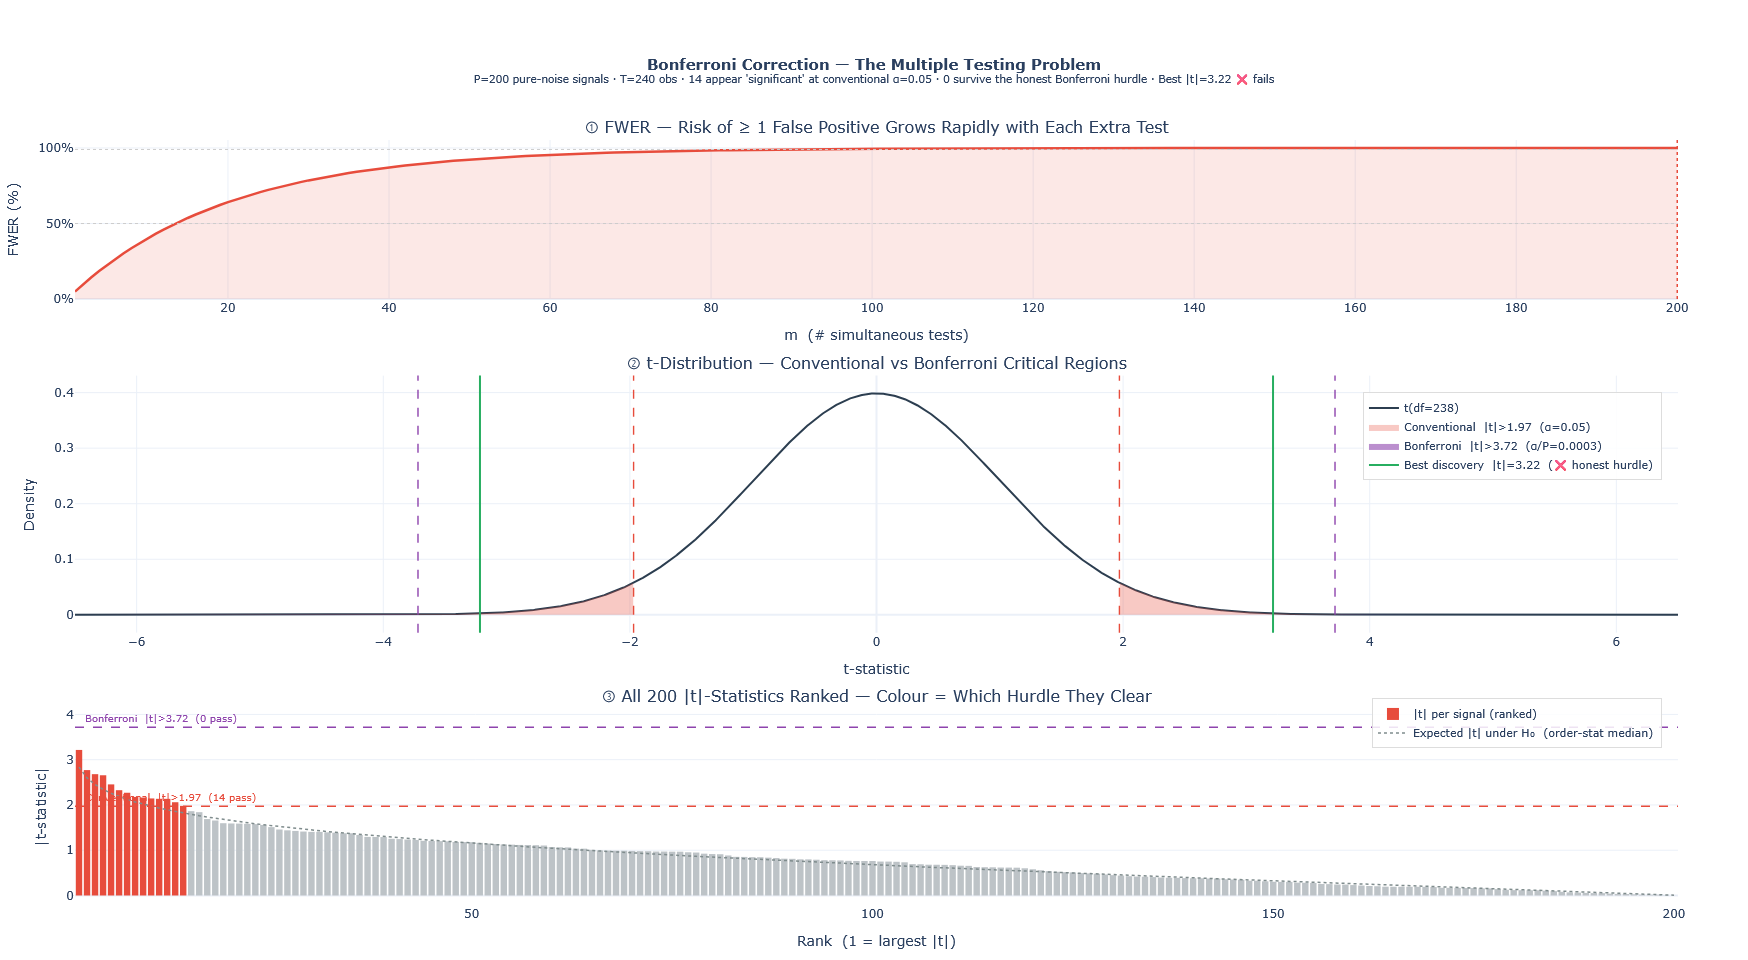

In [15]:
from __future__ import annotations

# ── 1 · Thresholds ─────────────────────────────────────────────────────────────
DF_T         = T - 2
ALPHA        = 0.05                                         # family-wise α

# ppf(1 - α/2)      — two-sided conventional
# ppf(1 - α/(2*P))  — Bonferroni: divide α equally among P tests
conventional = stats.t.ppf(1 - ALPHA / 2,       DF_T)
bonferroni   = stats.t.ppf(1 - ALPHA / (2 * P), DF_T)

n_conv = int((results.t_stat.abs() > conventional).sum())
n_bonf = int((results.t_stat.abs() > bonferroni).sum())
survives = abs(best_t) > bonferroni

print(f"Conventional |t| > {conventional:.2f}  →  {n_conv}/{P} signals 'significant'")
print(f"Bonferroni   |t| > {bonferroni:.2f}  →  {n_bonf}/{P} signals survive")
print(f"Best |t| = {abs(best_t):.2f}  — {'SURVIVES ✅' if survives else 'FAILS ❌'} Bonferroni")

# ── 2 · Figure scaffold ────────────────────────────────────────────────────────
subtitle = (
    f"P={P} pure-noise signals · T={T} obs · "
    f"{n_conv} appear 'significant' at conventional α=0.05 · "
    f"{n_bonf} survive the honest Bonferroni hurdle · "
    f"Best |t|={abs(best_t):.2f} {'✅ survives' if survives else '❌ fails'}"
)

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        "① FWER — Risk of ≥ 1 False Positive Grows Rapidly with Each Extra Test",
        "② t-Distribution — Conventional vs Bonferroni Critical Regions",
        f"③ All {P} |t|-Statistics Ranked — Colour = Which Hurdle They Clear",
    ],
    vertical_spacing=0.10,
    row_heights=[0.26, 0.42, 0.32],
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL 1 · FWER = 1 − (1 − α)^m
#
# Logic: if each of m independent tests has a type-I error rate of α, the
# probability of AT LEAST ONE false positive across the family is
#      FWER = 1 − P(no false positive) = 1 − (1 − α)^m
# At m=200, α=0.05: FWER ≈ 99.996 %.
# Bonferroni sets each test's α to α/m, restoring FWER ≤ α.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
m_arr  = np.arange(1, P + 1)
fwer   = (1 - (1 - ALPHA) ** m_arr) * 100   # as %
exp_fp = m_arr * ALPHA                       # expected # false positives

cdata1 = np.column_stack([m_arr, fwer, exp_fp]).tolist()

fig.add_trace(go.Scatter(
    x=m_arr, y=fwer,
    mode="lines",
    fill="tozeroy",
    fillcolor="rgba(231,76,60,0.13)",
    line=dict(color="#e74c3c", width=2.5),
    name="FWER  1−(1−α)^m",
    showlegend=False,
    customdata=cdata1,
    hovertemplate=(
        "<b>m = %{customdata[0]:.0f} simultaneous tests</b><br>"
        "P(≥1 false positive) = <b>%{customdata[1]:.1f}%</b><br>"
        "Expected false positives = <b>%{customdata[2]:.1f}</b><br>"
        "<i>Assuming every signal is pure noise</i>"
        "<extra></extra>"
    ),
), row=1, col=1)

# Reference lines and marker for P=200
for pct in (50, 99):
    fig.add_hline(y=pct, line_dash="dot", line_color="#ccc", line_width=1, row=1, col=1)
fig.add_vline(x=P, line_dash="dot", line_color="#e74c3c", line_width=1.5, row=1, col=1)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL 2 · t-distribution PDF
#
# Conventional: reject when |t| > t_{α/2, df}   ≈ 1.97  (tail prob. 2.5%)
# Bonferroni:   reject when |t| > t_{α/(2P), df} ≈ 3.72  (tail prob. 0.0125%)
# Each individual test now has so little room to reject that the family-wide
# probability of any mistake stays at or below α.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
x_pdf = np.linspace(-6.5, 6.5, 1500)
y_pdf = stats.t.pdf(x_pdf, DF_T)

# Full t-distribution curve
fig.add_trace(go.Scatter(
    x=x_pdf, y=y_pdf,
    mode="lines",
    line=dict(color="#2c3e50", width=2),
    name=f"t(df={DF_T})",
    hoverinfo="skip",
), row=2, col=1)


def _shade_tail(x_all, y_all, mask, fillcolor, name, showlegend):
    """Add a filled polygon for one tail of the distribution."""
    xs, ys = x_all[mask], y_all[mask]
    if len(xs) == 0:
        return
    fig.add_trace(go.Scatter(
        x=np.r_[xs[0], xs, xs[-1]],
        y=np.r_[0,     ys,    0],
        fill="toself", fillcolor=fillcolor,
        line=dict(width=0),
        name=name, showlegend=showlegend,
        hoverinfo="skip",
    ), row=2, col=1)


# Conventional rejection region (light red)
_shade_tail(x_pdf, y_pdf, x_pdf <= -conventional,
            "rgba(231,76,60,0.30)",
            f"Conventional  |t|>{conventional:.2f}  (α={ALPHA})", False)
_shade_tail(x_pdf, y_pdf, x_pdf >=  conventional,
            "rgba(231,76,60,0.30)",
            f"Conventional  |t|>{conventional:.2f}  (α={ALPHA})", True)

# Bonferroni rejection region (solid purple — much smaller!)
_shade_tail(x_pdf, y_pdf, x_pdf <= -bonferroni,
            "rgba(142,68,173,0.60)",
            f"Bonferroni  |t|>{bonferroni:.2f}  (α/P={ALPHA/P:.4f})", False)
_shade_tail(x_pdf, y_pdf, x_pdf >=  bonferroni,
            "rgba(142,68,173,0.60)",
            f"Bonferroni  |t|>{bonferroni:.2f}  (α/P={ALPHA/P:.4f})", True)

# Vertical threshold lines
for xval, col, dash, wid in [
    ( conventional, "#e74c3c", "dash",  1.4),
    (-conventional, "#e74c3c", "dash",  1.4),
    ( bonferroni,   "#8e44ad", "dash",  1.4),
    (-bonferroni,   "#8e44ad", "dash",  1.4),
    ( abs(best_t),  "#27ae60", "solid", 2.0),   # best discovery
    (-abs(best_t),  "#27ae60", "solid", 2.0),
]:
    fig.add_vline(x=xval, line_dash=dash, line_color=col, line_width=wid, row=2, col=1)

# Best-discovery marker in the legend
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode="lines",
    line=dict(color="#27ae60", width=2),
    name=f"Best discovery  |t|={abs(best_t):.2f}  ({'✅' if survives else '❌'} honest hurdle)",
), row=2, col=1)

# ── Invisible hover-able scatter across the PDF curve ──────────────────────────
# Lets the user read off exact PDF/CDF/p-value at any point.
hx   = np.linspace(-5, 5, 300)
hpdf = stats.t.pdf(hx, DF_T)
hcdf = stats.t.cdf(hx, DF_T)
h2p  = 2 * np.minimum(hcdf, 1 - hcdf)   # two-sided p-value

fig.add_trace(go.Scatter(
    x=hx, y=hpdf,
    mode="markers",
    marker=dict(size=8, color="rgba(0,0,0,0)"),   # completely transparent
    name="PDF hover",
    showlegend=False,
    customdata=np.column_stack([hx, hpdf, hcdf, h2p]).tolist(),
    hovertemplate=(
        "t = <b>%{customdata[0]:.3f}</b><br>"
        "PDF  = %{customdata[1]:.5f}<br>"
        "CDF  = %{customdata[2]:.4f}<br>"
        "Two-sided p-value = <b>%{customdata[3]:.5f}</b>"
        "<extra></extra>"
    ),
), row=2, col=1)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL 3 · Ranked |t|-statistics
#
# Purple: survives Bonferroni (honest find)
# Red:    clears conventional threshold only (likely false positive)
# Grey:   not even conventionally significant
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
sorted_res = (
    results
    .reindex(results.t_stat.abs().sort_values(ascending=False).index)
    .reset_index()
    .rename(columns={"index": "signal"})
)
sorted_res["abs_t"] = sorted_res["t_stat"].abs()
sorted_res["rank"]  = np.arange(1, P + 1)


def _bar_color(t_abs: float) -> str:
    if t_abs > bonferroni:   return "#8e44ad"
    if t_abs > conventional: return "#e74c3c"
    return "#bdc3c7"


bar_colors = [_bar_color(v) for v in sorted_res["abs_t"]]

# Expected FP baseline (what the average |t|-rank looks like)
rank_arr   = sorted_res["rank"].values
expected_t = stats.t.ppf(1 - 0.5 * rank_arr / (P + 1), DF_T)   # order-statistic median

cdata3 = [
    [row["signal"],
     f"{row['t_stat']:+.3f}",
     f"{row['abs_t']:.3f}",
     f"{row['correlation']:+.3f}",
     f"{row['p_value']:.4f}",
     int(row["rank"]),
     ("✅ Survives Bonferroni  — honest find"
      if row["abs_t"] > bonferroni else
      "⚠️  Conventional only  — likely false positive"
      if row["abs_t"] > conventional else
      "◻  Not significant")]
    for _, row in sorted_res.iterrows()
]

fig.add_trace(go.Bar(
    x=sorted_res["rank"],
    y=sorted_res["abs_t"],
    marker=dict(color=bar_colors, line_width=0),
    name="|t| per signal (ranked)",
    legend="legend2",
    customdata=cdata3,
    hovertemplate=(
        "<b>%{customdata[0]}</b>  (rank #%{customdata[5]})<br>"
        "t = %{customdata[1]}     |t| = %{customdata[2]}<br>"
        "r = %{customdata[3]}     p-value = %{customdata[4]}<br>"
        "<b>%{customdata[6]}</b>"
        "<extra></extra>"
    ),
), row=3, col=1)

# Expected-value envelope (order-statistic median under H₀ — all noise)
fig.add_trace(go.Scatter(
    x=rank_arr,
    y=expected_t,
    mode="lines",
    line=dict(color="#7f8c8d", width=1.5, dash="dot"),
    name="Expected |t| under H₀  (order-stat median)",
    legend="legend2",
    hovertemplate=(
        "Rank #%{x}<br>"
        "Expected |t| = <b>%{y:.3f}</b>  if all signals are noise"
        "<extra></extra>"
    ),
), row=3, col=1)

# Threshold lines
fig.add_hline(
    y=conventional,
    line_dash="dash", line_color="#e74c3c", line_width=1.5,
    annotation_text=f"  Conventional  |t|>{conventional:.2f}  ({n_conv} pass)",
    annotation_position="top left",
    annotation_font=dict(color="#e74c3c", size=10),
    row=3, col=1,
)
fig.add_hline(
    y=bonferroni,
    line_dash="dash", line_color="#8e44ad", line_width=1.5,
    annotation_text=f"  Bonferroni  |t|>{bonferroni:.2f}  ({n_bonf} pass)",
    annotation_position="top left",
    annotation_font=dict(color="#8e44ad", size=10),
    row=3, col=1,
)

# ── 3 · Global layout ──────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            "<b>Bonferroni Correction — The Multiple Testing Problem</b>"
            f"<br><sup>{subtitle}</sup>"
        ),
        x=0.5, xanchor="center", font_size=15,
    ),
    height=960,
    template="plotly_white",
    hovermode="closest",
    showlegend=True,
    legend=dict(
        orientation="v",
        x=0.99, y=0.67, xanchor="right", yanchor="top",
        font_size=11,
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="#ddd", borderwidth=1,
    ),
    legend2=dict( # Panel ③ items (ranked bars)
        orientation="v",
        x=0.99, y=0.27, # top-right corner of Panel ③ domain
        xanchor="right", yanchor="top",
        font_size=11,
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="#ddd", borderwidth=1,
    ),
    margin=dict(l=70, r=70, t=140, b=55),
)

fig.update_yaxes(title_text="FWER (%)",          ticksuffix="%",         row=1, col=1)
fig.update_xaxes(title_text="m  (# simultaneous tests)",                  row=1, col=1)
fig.update_yaxes(title_text="Density",                                    row=2, col=1)
fig.update_xaxes(title_text="t-statistic",        range=[-6.5, 6.5],     row=2, col=1)
fig.update_yaxes(title_text="|t-statistic|",                              row=3, col=1)
fig.update_xaxes(title_text="Rank  (1 = largest |t|)",                    row=3, col=1)

fig.show()
# fig.write_html("bonferroni_explainer.html")   # ← uncomment to save

## What you have just done

You searched a space, found the best thing in it, and mistook the search for a
discovery. Both acts are the same error wearing different clothes.

**This is not a story about carelessness.** The p-value was computed correctly. The
correlation is real in the sample. The manager's returns actually happened. Every
individual number was true, and the conclusion was still wrong — because the numbers
were selected *after* looking.

Three things follow, and they are the spine of today's lecture:

1. **The published literature has run this search for sixty years.** Hundreds of
   return predictors have been documented. How many are real?
2. **The conventional hurdle is wrong when you have searched.** How much higher should
   it be, and who decides?
3. **If we cannot trust selection, what do we do instead?** The answer turns out to be
   shrinkage, and it is more interesting than it sounds.

Bring your answer to question 1 to the lecture. Most people guess far too high.

---
# Coda — Name that factor

Five minutes. This also confirms your environment is ready for this week's labs.

Before running anything: **write down every return predictor you can name.** Value,
momentum, size — keep going. Then put them in the list below.

In [16]:
# Your list. Plain English is fine: "momentum", "value", "accruals", ...
MY_FACTORS = [
    "momentum",
    "value",
    "size",
]

try:
    zoo = airm8.load_open_source_zoo(balanced_from=None, min_coverage=None)
    HAVE_DATA = True
    print(f"Loaded {zoo.shape[1]} published, replicated return predictors.")
    print(f"Coverage: {zoo.index.min():%Y-%m} to {zoo.index.max():%Y-%m}")
except Exception as err:
    HAVE_DATA = False
    print(f"Could not load the factor data: {type(err).__name__}")
    print(f"{err}\n")
    print("Tell your tutor before the lab — this needs fixing for Lecture 8b.")

Loaded 212 published, replicated return predictors.
Coverage: 1926-01 to 2024-12


In [17]:
if HAVE_DATA:
    names = pd.Series(zoo.columns)
    lower = names.str.lower()

    print(f"You named {len(MY_FACTORS)}. Matching against "
          f"{len(names)} published predictors:\n")
    matched = set()
    for guess in MY_FACTORS:
        key = guess.lower().replace(" ", "")
        hits = names[lower.str.contains(key[:6], regex=False)].tolist()
        matched.update(hits)
        print(f"   {guess:16s} -> {', '.join(hits[:4]) if hits else 'no obvious match'}")

    print(f"\n   You accounted for roughly {len(matched)} of {len(names)}.")
    print(f"   That leaves about {len(names) - len(matched)} you did not name.")

You named 3. Matching against 212 published predictors:

   momentum         -> CustomerMomentum, ResidualMomentum
   value            -> AnalystValue
   size             -> Size

   You accounted for roughly 4 of 212.
   That leaves about 208 you did not name.


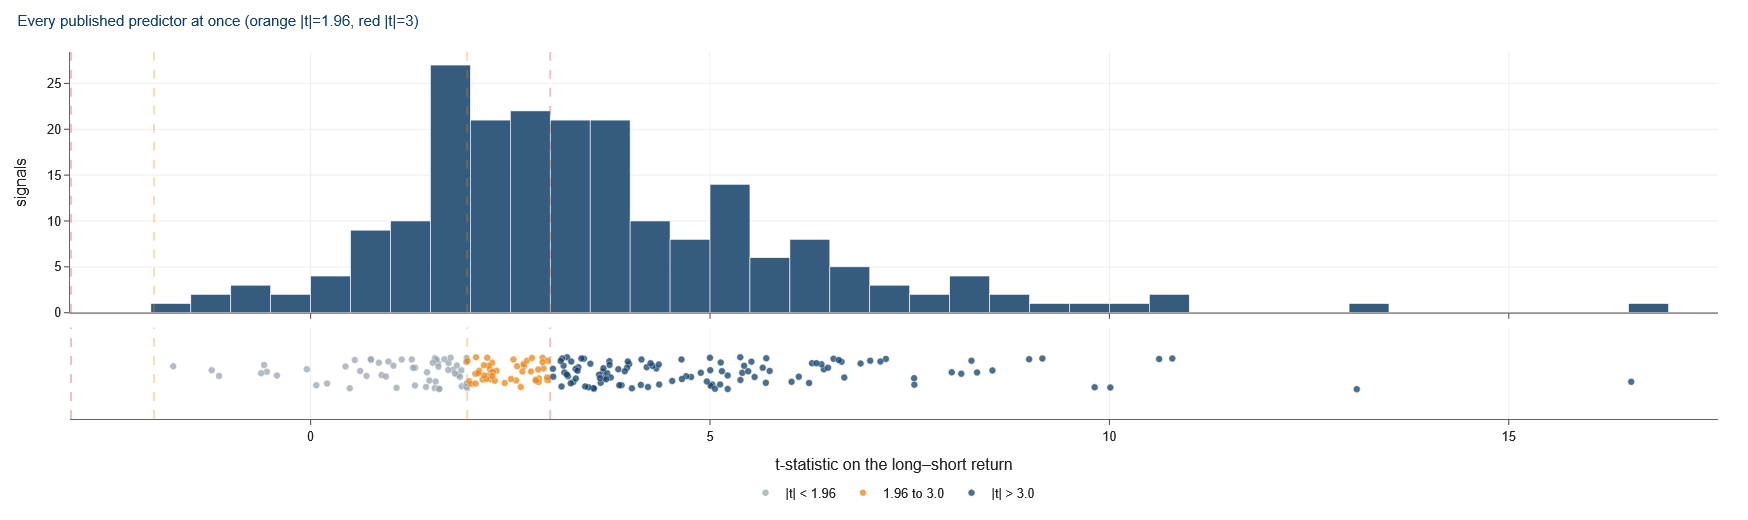

212 predictors, 1975 onwards.
Hover any point in the strip to see which anomaly it is —
the name, its Sharpe ratio, and how many months it is based on.


In [18]:
if HAVE_DATA:
    st = airm8.signal_stats(zoo.loc["1975":]).dropna()

    fig = airm8.plot_signal_distribution(
        st, title="Every published predictor at once "
                  "(orange |t|=1.96, red |t|=3)")
    # .show() is required here: the figure is built inside an `if` block, and
    # Jupyter only auto-displays the last expression when it sits at the top
    # level of the cell. Without it the figure is built and silently dropped.
    fig.show()

    print(f"{len(st)} predictors, 1975 onwards.")
    print("Hover any point in the strip to see which anomaly it is —")
    print("the name, its Sharpe ratio, and how many months it is based on.")

The histogram gives you the shape; the strip beneath gives you the names. **Hover
over the far right tail.** Those are not obscure curiosities — they are published,
replicated anomalies with t-statistics above 10.

Then ask the question this warm-up has been building towards: in Act 2, fourteen
pure-noise signals cleared $|t| > 1.96$, and the best reached 3.22. Where on this
picture would those fourteen have landed?

In [20]:
if HAVE_DATA:
    print("The five strongest published predictors since 1975:\n")
    top = st.reindex(st.tstat.abs().sort_values(ascending=False).index).head()
    print(top[["sharpe", "tstat", "n_obs"]].round(2).to_string())
    print(f"\nPredictors clearing |t| > 1.96:  {(st.tstat.abs() > 1.96).sum():3d} of {len(st)}")
    print(f"Predictors clearing |t| > 3.00:  {(st.tstat.abs() > 3.00).sum():3d} of {len(st)}")
    print(f"\nNote the n_obs column: these do not share a sample. Some signals")
    print("need data that only exists from the 1990s, so a long history and a")
    print("high t-statistic are not the same achievement.")

The five strongest published predictors since 1975:

                    sharpe  tstat  n_obs
DivSeason             2.34  16.53    600
AnnouncementReturn    1.85  13.10    600
SmileSlope            2.08  10.79    324
EarningsStreak        1.68  10.62    482
DivYieldST            1.42  10.01    600

Predictors clearing |t| > 1.96:  156 of 212
Predictors clearing |t| > 3.00:  111 of 212

Note the n_obs column: these do not share a sample. Some signals
need data that only exists from the 1990s, so a long history and a
high t-statistic are not the same achievement.


That is the **factor zoo**, and it is the subject of the lecture.

Now hold Act 3 in your mind while you look at it. Those are real, published,
peer-reviewed, independently replicated findings. Most of them clear the
conventional hurdle. In Act 2, so did twelve pure-noise signals.

**The distributions look alike. Telling them apart is the entire problem.**

---

## Three questions to bring to the lecture

1. In Act 1 we showed you the best of 1,000 traders. Roughly how many strategies do
   you think a large quantitative fund tests before launching one?

2. In Act 3 the honest hurdle for 200 tests was around $|t| > 3.7$. The factor
   literature has tested many more than 200 candidates. What hurdle would that imply,
   and is it a hurdle anyone could realistically clear?

3. Suppose you decide the hurdle is unknowable and refuse to select at all — you keep
   every one of the several hundred predictors. What could you possibly do with them?

*The answer to question 3 is the second half of the lecture, and it is not "give up".*